 conda activate hmm
 which pip (pip es el del environment)
 pip install git+https://github.com/mattjj/pybasicbayes
 pip install git+https://github.com/mattjj/pyhsmm

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [2]:
emissions=pd.read_csv('../data/hmm_input/emissions_11.csv')
print(type(emissions))
emissions

<class 'pandas.core.frame.DataFrame'>


,id,date,time,hour,weekday,steps,HR,intensity
0,1,2019-01-26,2019-01-26T08:00:00Z,8,Sat,0.0,65.0,0
1,1,2019-01-26,2019-01-26T08:01:00Z,8,Sat,0.0,64.0,0
2,1,2019-01-26,2019-01-26T08:02:00Z,8,Sat,0.0,63.0,0
3,1,2019-01-26,2019-01-26T08:03:00Z,8,Sat,0.0,73.0,0
4,1,2019-01-26,2019-01-26T08:04:00Z,8,Sat,0.0,66.0,0
...,...,...,...,...,...,...,...,...
226795,1,2020-09-23,2020-09-23T19:55:00Z,19,Wed,15.0,91.0,1
226796,1,2020-09-23,2020-09-23T19:56:00Z,19,Wed,0.0,88.0,0
226797,1,2020-09-23,2020-09-23T19:57:00Z,19,Wed,0.0,87.0,0
226798,1,2020-09-23,2020-09-23T19:58:00Z,19,Wed,0.0,86.0,0


(array([2.0653e+05, 8.1110e+03, 4.4800e+03, 2.7700e+03, 1.5440e+03,
        9.6700e+02, 6.2900e+02, 8.8000e+01, 5.8000e+01, 5.2000e+01]),
 array([  0. ,  17.3,  34.6,  51.9,  69.2,  86.5, 103.8, 121.1, 138.4,
        155.7, 173. ]),
 <BarContainer object of 10 artists>)

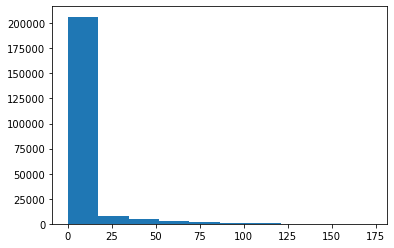

In [3]:
plt.hist(emissions.steps.values)

(array([2.5640e+03, 4.5995e+04, 8.2148e+04, 5.4087e+04, 3.3597e+04,
        6.2300e+03, 4.2900e+02, 1.3800e+02, 4.0000e+01, 1.0000e+00]),
 array([ 44. ,  58.1,  72.2,  86.3, 100.4, 114.5, 128.6, 142.7, 156.8,
        170.9, 185. ]),
 <BarContainer object of 10 artists>)

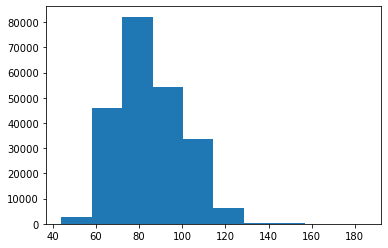

In [4]:
plt.hist(emissions.HR)

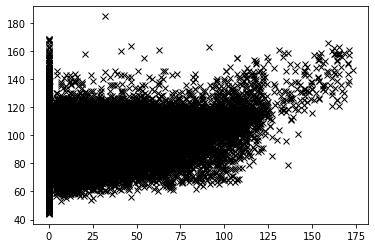

In [5]:
#### plot scatterplot
plt.plot(
    emissions.steps.values,
    emissions.HR.values,
    'kx'
)

### #### ####

 Standardize columns

### #### ####

In [6]:
mu_steps = emissions['steps'].mean()
mu_HR = emissions['HR'].mean()
sd_steps = emissions['steps'].std()
sd_HR = emissions['HR'].std()

In [7]:
#### for  Standardize columns
# for var in df.columns:
#    mu = df[var].mean()
#    sig = df[var].std()
#    df[var] = (df[var] - mu) / sig

In [8]:
#### broadcasting  Standardize columns
# mat = df.values
# mat -= mat.mean(axis=0, keepdims=True)
# mat /= mat.std(axis=0, keepdims=True)

Data preparation considerations
* eight-to-eight breaks the continuous time
* standardization is applied over all values in the time series using a single mean and sd

In [9]:
#### pandas  Standardize columns
from sklearn.preprocessing import *
df = pd.DataFrame(
    StandardScaler().fit_transform(emissions[['steps','HR']]), 
    index=emissions[['steps','HR']].index, 
    columns=emissions[['steps','HR']].columns
    )

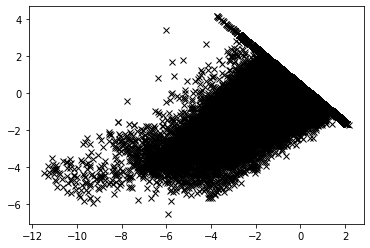

In [10]:
from pyhsmm.util.plot import pca_project_data
plt.plot(
    pca_project_data(df.values,1)[:,0],
    pca_project_data(df.values,2)[:,1],
    'kx'
)

In [11]:
print(
    "na steps:", sum(np.isnan(df.steps.values)),
    "na HR", sum(np.isnan(df.HR.values))
)

na steps: 1571 na HR 1571


In [12]:
df['steps'] = df['steps'].fillna(-10)
df['HR'] = df['HR'].fillna(0)

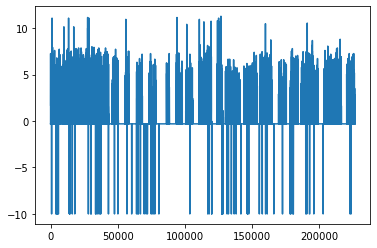

In [13]:
plt.plot(df.steps)

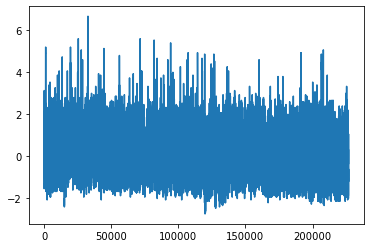

In [14]:
plt.plot(df.HR)

In [15]:
obs_dim = 2
Nmax = 4

obs_hypparams = {'mu_0':np.zeros(obs_dim),
                'sigma_0':np.eye(obs_dim),
                'kappa_0':0.3,
                'nu_0':obs_dim+1}
dur_hypparams = {'alpha_0':2*30,
                 'beta_0':2}

In [16]:
import pyhsmm
import pyhsmm.basic.distributions as distributions
obs_distns = [distributions.Gaussian(**obs_hypparams) for state in range(Nmax)]
dur_distns = [distributions.PoissonDuration(**dur_hypparams) for state in range(Nmax)]

In [17]:
obs_distns

In [18]:
dur_distns

In [19]:
posteriormodel = pyhsmm.models.WeakLimitHDPHSMM(
        alpha=6.,gamma=6., # better to sample over these; see concentration-resampling.py
        init_state_concentration=6., # pretty inconsequential
        obs_distns=obs_distns,
        dur_distns=dur_distns)

In [26]:
posteriormodel.add_data(df.values, trunc=(720)) #720 min = 12h (eight to eight)
#trunc is the max length of a state

In [27]:
dist_0 = obs_distns[0]

In [28]:
dist_0.mu

array([0.8345751 , 1.25695147])

In [29]:
dist_0.sigma

array([[0.41022987, 0.25429389],
       [0.25429389, 1.32884545]])

In [30]:
dur_0 = dur_distns[0]
dur_0.alpha_0

60

In [31]:
posteriormodel.stateseqs[0]

array([1, 1, 1, ..., 3, 3, 3], dtype=int32)

In [32]:
import copy
from pybasicbayes.util.text import progprint_xrange
models = []
for idx in progprint_xrange(250):
    posteriormodel.resample_model()
    if (idx+1) % 25 == 0:
        models.append(copy.deepcopy(posteriormodel))

.........................  [  25/250,   19.20sec avg, ETA 01:12:01 ]
.........................  [  50/250,   19.09sec avg, ETA 01:03:39 ]
.........................  [  75/250,   19.01sec avg, ETA 55:27 ]
.........................  [ 100/250,   20.09sec avg, ETA 50:13 ]
.........................  [ 125/250,   19.85sec avg, ETA 41:21 ]
.........................  [ 150/250,   25.76sec avg, ETA 42:56 ]
.........................  [ 175/250,   24.78sec avg, ETA 30:58 ]
.........................  [ 200/250,   24.03sec avg, ETA 20:01 ]
.........................  [ 225/250,   23.45sec avg, ETA 09:46 ]
.........................  [ 250/250,   23.01sec avg, ETA 0.00 ]

  23.01sec avg, 01:35:53 total



In [33]:
len(models)

10

In [ ]:
import pickle
pickle.dump(models, open("models_007.pkl", "wb" ))
#models = pickle.load(open("models_007.pkl", "rb" )

Text(0.5, 0.98, 'HDP-HSMM sampled after 25 iterations')

<Figure size 432x288 with 0 Axes>

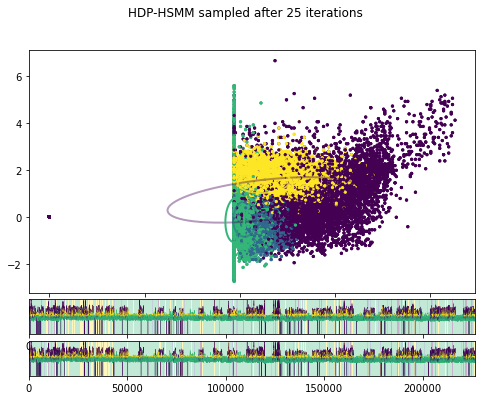

In [34]:
idx = 0
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

Text(0.5, 0.98, 'HDP-HSMM sampled after 50 iterations')

<Figure size 432x288 with 0 Axes>

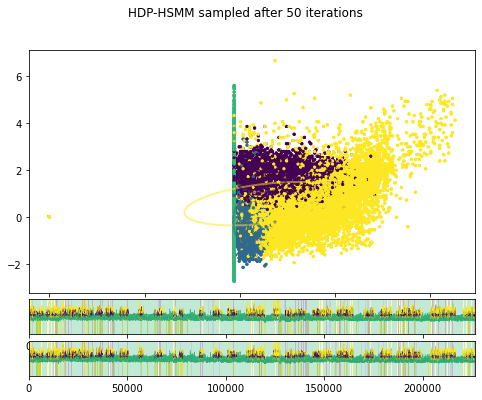

In [35]:
idx = 1
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

Text(0.5, 0.98, 'HDP-HSMM sampled after 75 iterations')

<Figure size 432x288 with 0 Axes>

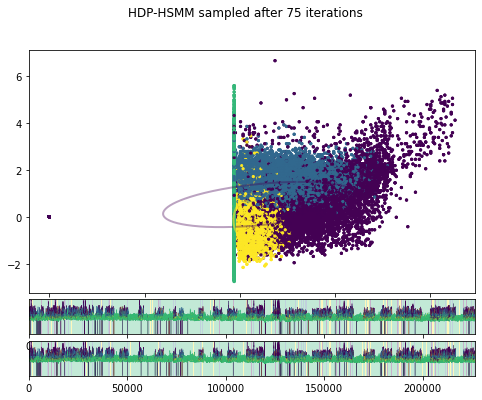

In [36]:
idx = 2
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

In [ ]:
idx = 3
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

Text(0.5, 0.98, 'HDP-HSMM sampled after 125 iterations')

<Figure size 432x288 with 0 Axes>

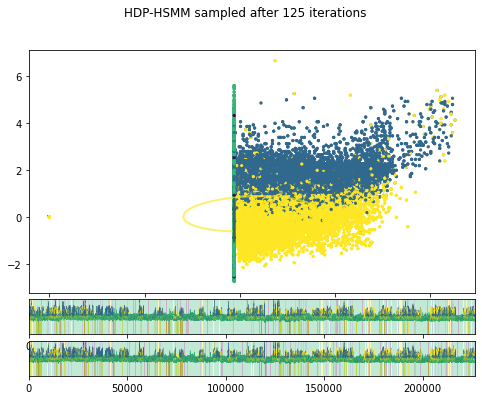

In [37]:
idx = 4
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

Text(0.5, 0.98, 'HDP-HSMM sampled after 150 iterations')

<Figure size 432x288 with 0 Axes>

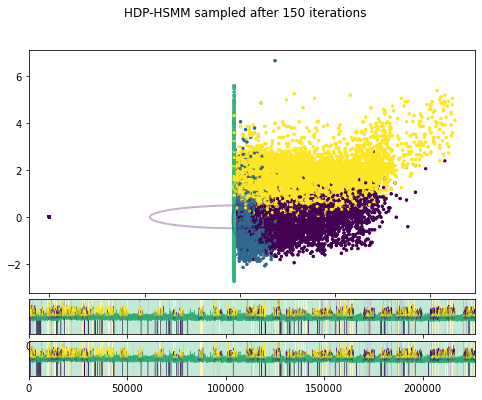

In [40]:
idx = 5
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

Text(0.5, 0.98, 'HDP-HSMM sampled after 175 iterations')

<Figure size 432x288 with 0 Axes>

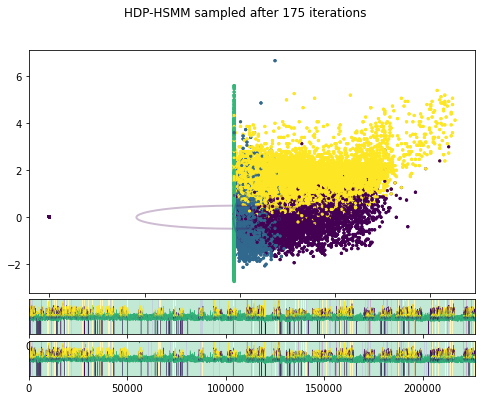

In [41]:
idx = 6
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

Text(0.5, 0.98, 'HDP-HSMM sampled after 200 iterations')

<Figure size 432x288 with 0 Axes>

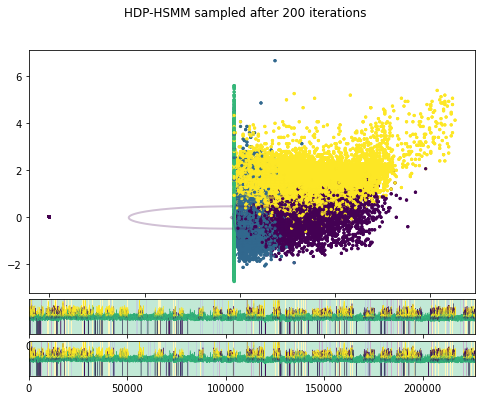

In [42]:
idx = 7
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

Text(0.5, 0.98, 'HDP-HSMM sampled after 225 iterations')

<Figure size 432x288 with 0 Axes>

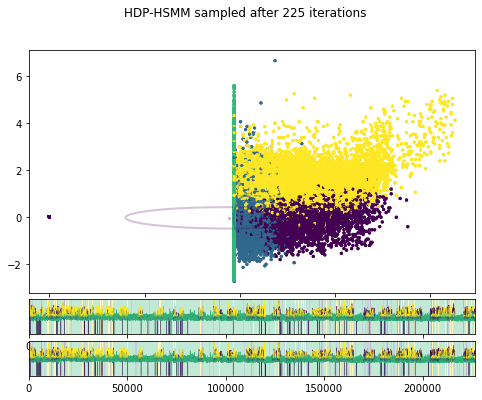

In [43]:
idx = 8
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

Text(0.5, 0.98, 'HDP-HSMM sampled after 250 iterations')

<Figure size 432x288 with 0 Axes>

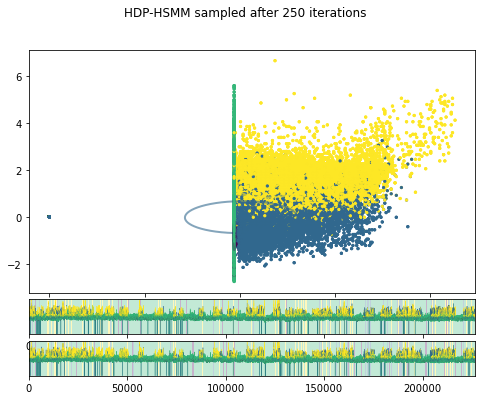

In [44]:
idx = 9
plt.clf()
models[idx].plot()
plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
#plt.savefig('iter_%.3d.png' % (10*(idx+1)))

<Figure size 432x288 with 0 Axes>

<Figure size 576x432 with 0 Axes>

<Figure size 576x432 with 0 Axes>

<Figure size 576x432 with 0 Axes>

<Figure size 576x432 with 0 Axes>

<Figure size 576x432 with 0 Axes>

<Figure size 576x432 with 0 Axes>

<Figure size 576x432 with 0 Axes>

<Figure size 576x432 with 0 Axes>

<Figure size 576x432 with 0 Axes>

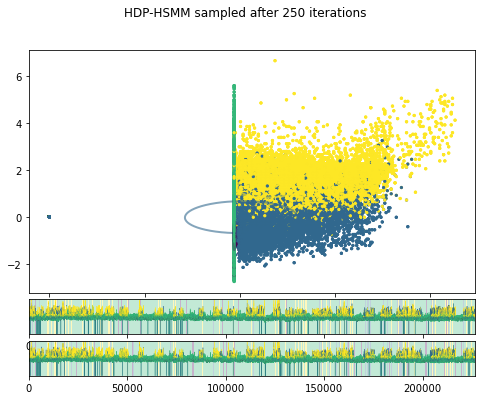

In [47]:
fig = plt.figure()
for idx, model in enumerate(models):
    plt.clf()
    model.plot()
    plt.gcf().suptitle('HDP-HSMM sampled after %d iterations' % (25*(idx+1)))
    plt.savefig('../data/hmm_output/ex_1/iter_%.3d.png' % (25*(idx+1)))

In [ ]:
for idx, model in enumerate(models):
    print("model", idx, "num_states:", model.num_states)
    print("model", idx, "used_states:", len(model.used_states))

In [ ]:
model0 = models[-1]

In [ ]:
df.shape

In [ ]:
dur0 = model0.dur_distns[0]
dur1 = model0.dur_distns[1]
dur2 = model0.dur_distns[2]
dur3 = model0.dur_distns[3]
dur4 = model0.dur_distns[4]
print(
    dur0.mean, 
    dur1.mean, 
    dur2.mean, 
    dur3.mean, 
    dur4.mean)

In [ ]:
from tqdm import tqdm
nsims = 100

M = df.shape[0]  # number of data points
counts = np.zeros((M, Nmax), dtype=int)  # M x number of components
for _ in tqdm(range(nsims)):
    z = model0.stateseqs[0]  # outputs a list of M values
    # for i, zi in enumerate(z):
    #     counts[i, zi] += 1
    counts[(np.arange(M), z)] += 1  # same as two lines above vectorized
    model0.resample_states()

counts[-1]  # first row

In [ ]:
probs = counts / nsims
entropy = - np.sum(np.log(1e-6 + probs) * probs, axis=-1)
plt.hist(entropy);

In [ ]:
import seaborn as sns

sns.scatterplot(x=df.steps, y=df.HR, hue=entropy)
plt.title("Uncertainty of hidden state belonging")

In [ ]:
most_uncertain = entropy.argsort()[-10:]
print(most_uncertain)
print(probs[most_uncertain])

In [ ]:
nsamples = len(models)  # num of posterior samples
Mu = np.zeros((nsamples, Nmax, 2))

dfcomps = []
for i, m in enumerate(models):
    for j, dist in enumerate(m.obs_distns):
        Mu[i, j, :] = dist.mu
Mu[-1]

In [ ]:
steps_comps = pd.DataFrame(Mu[:, :5, 0])
steps_comps.plot(figsize=(10, 3))
plt.xlabel("MCMC samples")
plt.ylabel("Steps")

In [ ]:
HR_comps = pd.DataFrame(Mu[:, :5, 1])
HR_comps.plot(figsize=(10, 3))
plt.xlabel("MCMC samples")
plt.ylabel("HR")

In [ ]:
# counts accross all posterior samples

from tqdm import tqdm

nsamples = len(models)
nsims = 10
M = df.shape[0]  # number of data points

counts = np.zeros((nsamples, M, Nmax), dtype=int)  # M x number of components
for k in range(nsamples):
    model0 = models[-k]
    print(f"Sampling model {k + 1}/{nsamples}")
    for _ in tqdm(range(nsims)):
        z = model0.stateseqs[0]  # outputs a list of M values
        # for i, zi in enumerate(z):
        #     counts[i, zi] += 1
        counts[k][(np.arange(M), z)] += 1  # same as two lines above vectorized
        model0.resample_states()

counts[0, -1]  # first row

In [ ]:
probs = counts / counts.sum(-1, keepdims=True)
marginal = probs.sum(1) / df.shape[0]
pd.DataFrame(marginal).plot(figsize=(8,3))
plt.title("Marginal distribution per component")